In [ ]:
import matplotlib.pyplot as plt
import csv

In [ ]:
def plotkvsaccuracy(model_size: int, exp_name:str):
    file_path = f"/space/poorvagarg/genPPS/{exp_name}/report/Qwen/Qwen2.5-Coder-{model_size}B-Instruct/0.7/accuracy.csv"
    data_list = []

    with open(file_path, mode='r', newline='') as csv_file:
        csv_reader = csv.reader(csv_file, delimiter=',')
        for row in csv_reader:
            data_list.append(row)

    data_list = data_list[1 if exp_name == "gsm8k" else 2:]

    def plot_pp_data(ax, num_samples):
        pp_data_list = list(filter(lambda x: int(x[1]) == num_samples + (0 if exp_name == "gsm8k" else 1), data_list))
        # num_samples = 0
        x = [int(i[0])*(num_samples+1) for i in pp_data_list]
        y = [float(i[2]) for i in pp_data_list]
        ax.plot(x, y)

    fig, ax = plt.subplots()
    plot_pp_data(ax, 0)
    plot_pp_data(ax, 1)
    plot_pp_data(ax, 5)
    plot_pp_data(ax, 10)
    plot_pp_data(ax, 20)
    ax.set_xlabel("k", fontsize=17)
    ax.set_ylabel("pass@k", fontsize=17)
    ax.legend(["k LLM", "k LLM + 1 PP", "k LLM + 5 PP", "k LLM + 10 PP", "k LLM + 20 PP"], fontsize=17)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_xlim(0, 40)
    ax.set_title(f"{model_size}B", fontsize=20)
    fig.savefig(f"/space/poorvagarg/genPPS/{exp_name}/plots/pass@k_{model_size}B.pdf", dpi=300)
    return fig

plotkvsaccuracy(0.5, "gsm8k")
plotkvsaccuracy(3, "gsm8k")
plotkvsaccuracy(7, "gsm8k")


In [ ]:
def plotkvstime(model_size: int, exp_name: str):
    folder_path = f"/space/poorvagarg/genPPS/{exp_name}/report/Qwen/Qwen2.5-Coder-{model_size}B-Instruct/0.7"
    data_list = []

    def plot_pp_data(ax, pp_samples):
        x = []
        y = []
        speedup = []
        for i in range(1, 15):
            pp_samples_file = 1 if pp_samples == 0 else pp_samples
            fast_suffix = "_fast" if exp_name == "gsm8k" else ""
            file_path = f"{folder_path}/time_{i}_{pp_samples_file}{fast_suffix}.txt"
            # print(file_path)
            # print(fast_suffix)
            with open(file_path, mode='r') as f:
                lines = f.readlines()
                x.append(i)
                line_idx = 3 if pp_samples == 0 else 7
                time = float(lines[line_idx].split(":")[1])
                baseline_time = float(lines[3].split(":")[1])
                speedup.append(time / baseline_time)
                y.append(time)
        print(min(speedup), max(speedup))
        ax.plot(x, y)

        

    fig, ax = plt.subplots()
    plot_pp_data(ax, 0)
    plot_pp_data(ax, 1)
    plot_pp_data(ax, 5)
    plot_pp_data(ax, 10)
    plot_pp_data(ax, 15)
    plot_pp_data(ax, 20)
    ax.set_xlabel("k", fontsize=17)
    ax.set_ylabel("time (in s)", fontsize=17)
    ax.legend(["k LLM", "k LLM + 1 PP", "k LLM + 5 PP", "k LLM + 10 PP", "k LLM + 15 PP", "k LLM + 20 PP"], fontsize=14)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_title(f"{model_size}B", fontsize=17)
    fig.savefig(f"/space/poorvagarg/genPPS/{exp_name}/plots/time_{model_size}B.pdf", dpi=300)
    return fig

plotkvstime(0.5, "gsm8k")
plotkvstime(3, "gsm8k")
plotkvstime(7, "gsm8k")

In [ ]:
plotkvsaccuracy(0.5, "cruxeval_new")
plotkvsaccuracy(3, "cruxeval_new")
plotkvsaccuracy(7, "cruxeval_new")

In [ ]:
plotkvstime(0.5, "cruxeval_new")
plotkvstime(3, "cruxeval_new")
plotkvstime(7, "cruxeval_new")

20 20
20 20
20 20
20 20
20 20
20 20
20 20
20 20
20 20
20 20


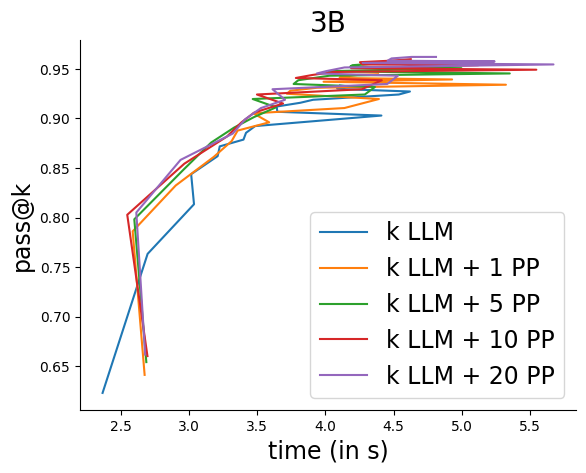

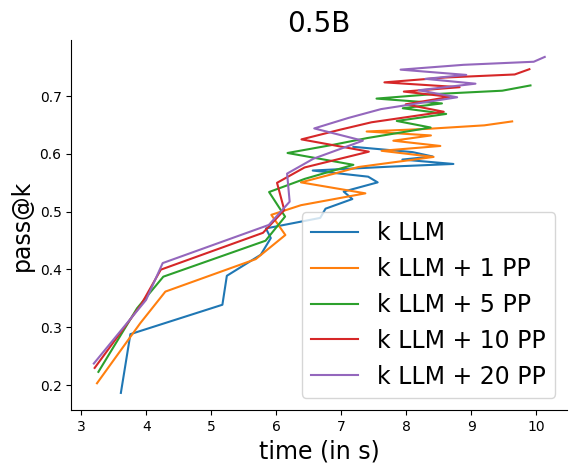

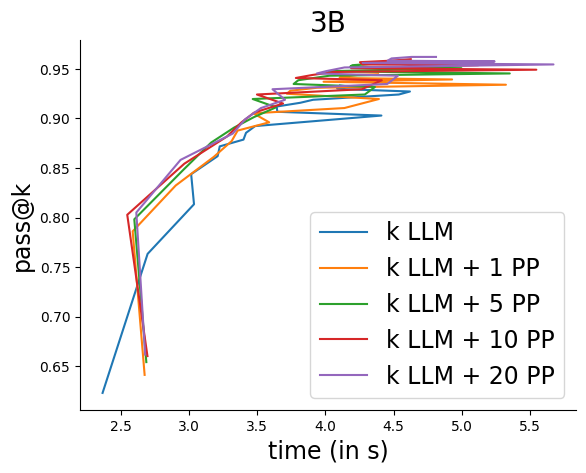

In [12]:
def plottimevsaccuracy(model_size: int, exp_name: str):
    folder_path = f"/space/poorvagarg/genPPS/{exp_name}/report/Qwen/Qwen2.5-Coder-{model_size}B-Instruct/0.7"

    def get_time_data(ax, pp_samples):
        x = []
        y = []
        speedup = []
        for i in range(1, 21):
            pp_samples_file = 1 if pp_samples == 0 else pp_samples
            fast_suffix = "_fast" if exp_name == "gsm8k" else ""
            file_path = f"{folder_path}/time_{i}_{pp_samples_file}{fast_suffix}.txt"
            # print(file_path)
            # print(fast_suffix)
            with open(file_path, mode='r') as f:
                lines = f.readlines()
                x.append(i)
                line_idx = 3 if pp_samples == 0 else 7
                time = float(lines[line_idx].split(":")[1])
                baseline_time = float(lines[3].split(":")[1])
                speedup.append(time / baseline_time)
                y.append(time)
        # print(min(speedup), max(speedup))
        return x, y
    
    file_path = f"/space/poorvagarg/genPPS/{exp_name}/report/Qwen/Qwen2.5-Coder-{model_size}B-Instruct/0.7/accuracy.csv"
    data_list = []

    with open(file_path, mode='r', newline='') as csv_file:
        csv_reader = csv.reader(csv_file, delimiter=',')
        for row in csv_reader:
            data_list.append(row)

    data_list = data_list[1 if exp_name == "gsm8k" else 2:]

    def get_accuracy_data(ax, num_samples):
        pp_data_list = list(filter(lambda x: int(x[1]) == num_samples + (0 if exp_name == "gsm8k" else 1), data_list))
        # num_samples = 0
        x = [int(i[0])*(num_samples+1) for i in pp_data_list]
        y = [float(i[2]) for i in pp_data_list]
        return x, y

    def plot_data(ax, num_samples):
        time_x, time_y = get_time_data(ax, num_samples)
        acc_x, acc_y = get_accuracy_data(ax, num_samples)
        print(len(time_y), len(acc_y))
        ax.plot(time_y, acc_y)

    fig, ax = plt.subplots()

    plot_data(ax, 0)
    plot_data(ax, 1)
    plot_data(ax, 5)
    plot_data(ax, 10)
    plot_data(ax, 20)
    ax.set_xlabel("time (in s)", fontsize=17)
    ax.set_ylabel("pass@k", fontsize=17)
    ax.legend(["k LLM", "k LLM + 1 PP", "k LLM + 5 PP", "k LLM + 10 PP", "k LLM + 20 PP"], fontsize=17)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    # ax.set_xlim(0, 40)
    ax.set_title(f"{model_size}B", fontsize=20)
    fig.savefig(f"/space/poorvagarg/genPPS/{exp_name}/plots/pass@k_time_{model_size}B.pdf", dpi=300)
    return fig
    
    
plottimevsaccuracy(0.5, "gsm8k")
plottimevsaccuracy(3, "gsm8k")
# plottimevsaccuracy(7, "gsm8k")